In [30]:
# --- IMPORTS ---
import pandas as pd              # Práca s tabuľkami (DataFrame)
import numpy as np               # Matematika a polia
import matplotlib.pyplot as plt  # Základné grafy
import seaborn as sns            # Krajšie štatistické grafy
import scipy.stats as stats      # Štatistické testy (T-testy, ANOVA...)
import statsmodels.api as sm     # Pokročilá štatistika (Regresia)
import statsmodels.formula.api as smf # R-style formuly pre regresiu

# Nastavenie dizajnu grafov
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

print("✅ Libraries successfully loaded!")

✅ Libraries successfully loaded!


In [31]:
try:
    df = pd.read_csv("../dataset/lifestyle.csv", sep=";")
    print("✅ Data successfully loaded.")
except FileNotFoundError:
    print("ERROR: File not found.")

df.head()

✅ Data successfully loaded.


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,BPs,BPd,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126,83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125,80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125,80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140,90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140,90,85,3000,Sleep Apnea


# Neparametricke testy
* typicky kategoricke data

## Test dobrej zhody (goodness-of-fit test)

**BMI category : Ordinal data**

** BMI Category** Frequency table

In [32]:
bmi_counts = df['BMI Category'].value_counts()
bmi_percent = df['BMI Category'].value_counts(normalize=True) * 100 # relativne zastupenie

total = bmi_counts.sum()
categories = 4

expected = total / categories

freq_table = pd.DataFrame({
    "Count (n)": bmi_counts,
    "Percents (%)": bmi_percent,
    "Expected": expected,
})
freq_table

,Count (n),Percents (%),Expected
BMI Category,,,
Normal,195,52.139037,93.5
Overweight,148,39.572193,93.5
Normal Weight,21,5.614973,93.5
Obese,10,2.673797,93.5


* V priemere by v kazdej kategorii malo byt 93.5 ludi z celkoveho poctu ludi napriec 4 kategoriami.
* Su odchylky zasadne? Testovanie hypotezy, chi kvadrat rozdelenie
  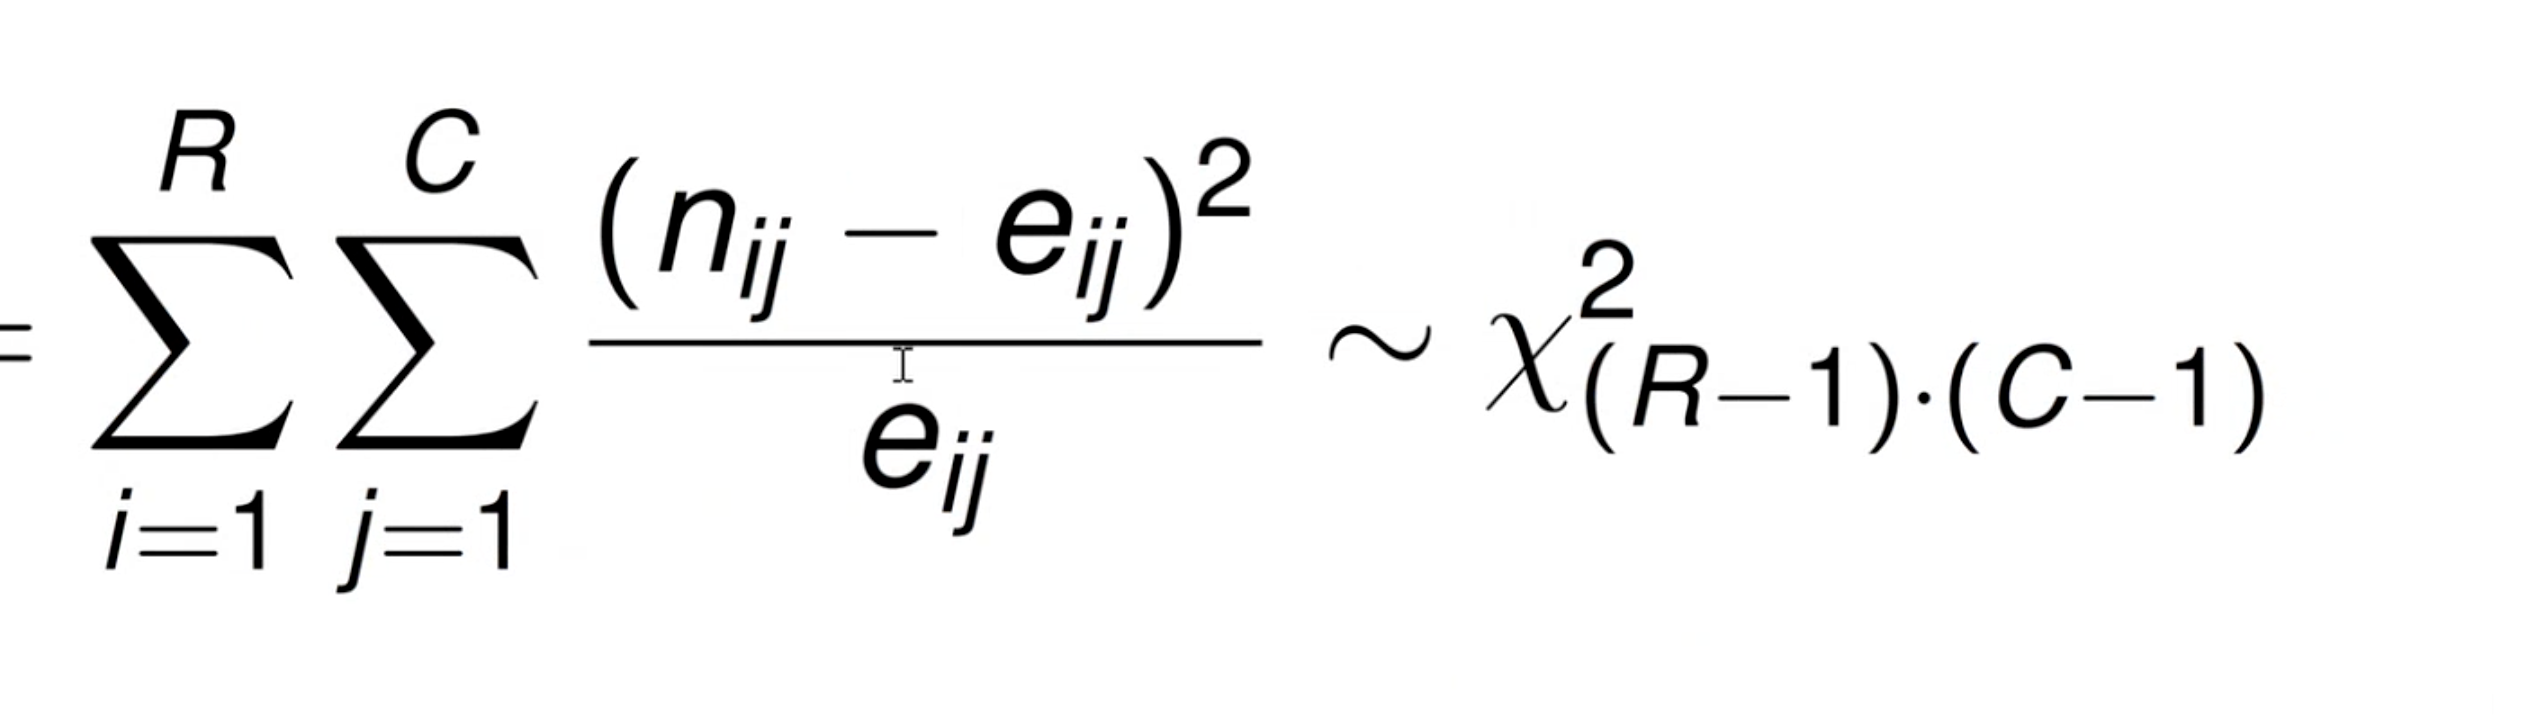

In [33]:
chi_contributions = (bmi_counts - expected)**2 / expected
chi_contributions

BMI Category
Normal           110.184492
Overweight        31.767380
Normal Weight     56.216578
Obese             74.569519
Name: count, dtype: float64

In [34]:
chi_square_stat = np.sum(chi_contributions)
print(f"Celkova statistika Chi-kvadrat (X) {chi_square_stat:.4f}")

Celkova statistika Chi-kvadrat (X) 272.7380


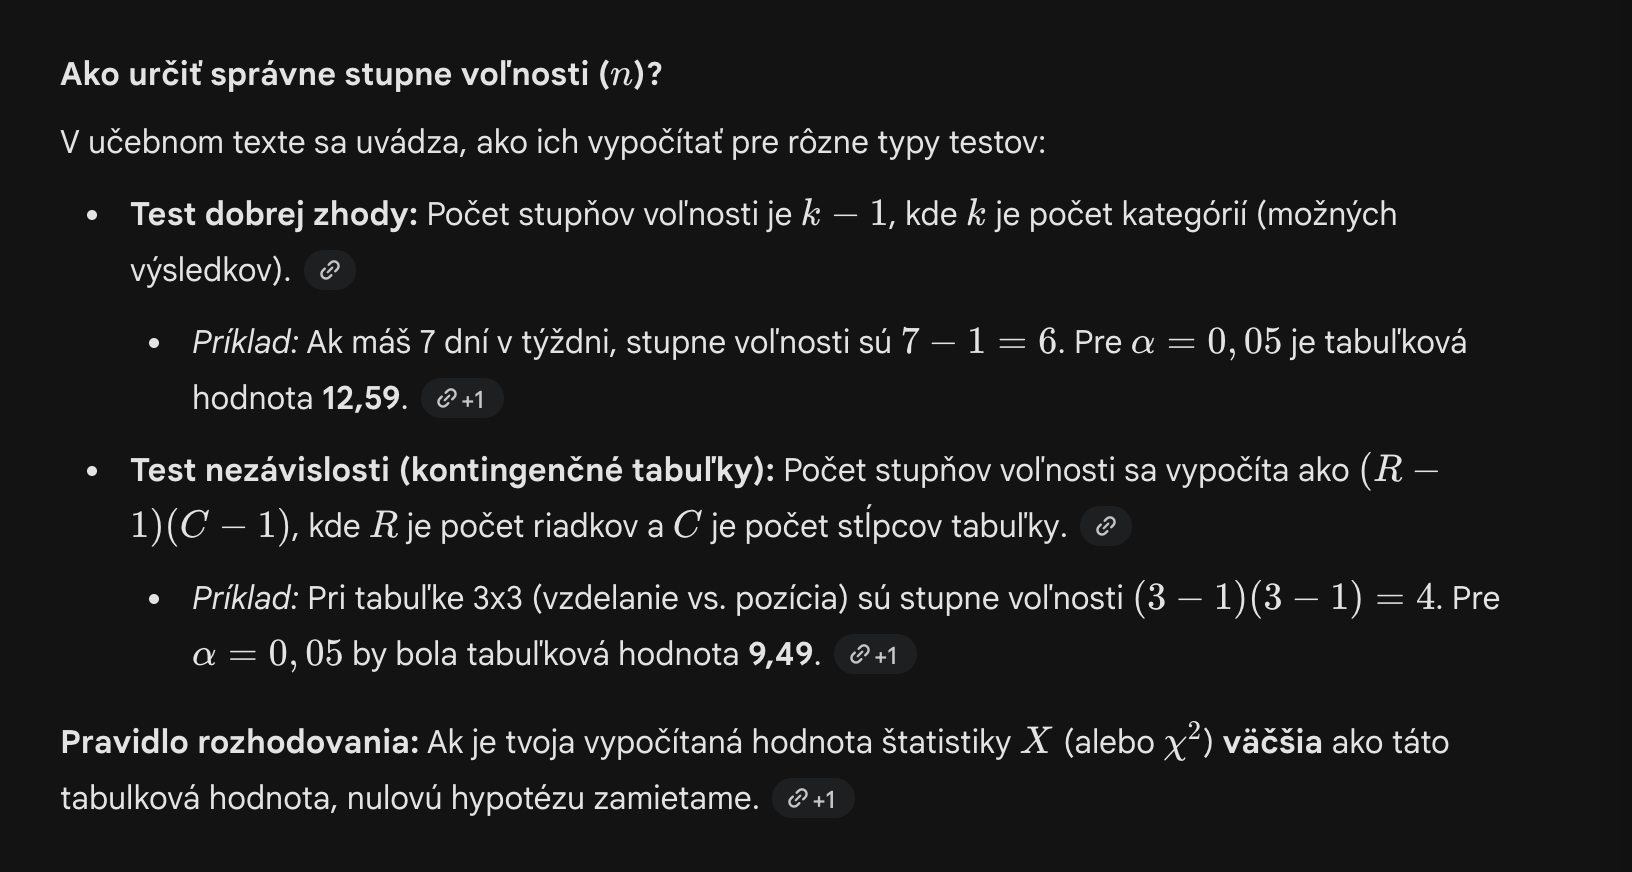

In [37]:
# Chi tabulkova hodnota
alpha = 0.05 # Hladina vyznamnosti
p = 1 - alpha # Kumulativna pravdepodobnost
dfreedom = categories - 1

# Funkcia chi2.ppf vráti hodnotu x, pre ktorú platí P(X < x) = p
critical_value = stats.chi2.ppf(p, dfreedom)
# Cumulative Distribution Function
p_value = 1 - stats.chi2.cdf(chi_square_stat, dfreedom)

print(f"Critical table value for df = {dfreedom} and alpha = {alpha}: (X) {critical_value:.4f}")
print(f"P-hodnota: {p_value:.4e}")

Critical table value for df = 3 and alpha = 0.05: (X) 7.8147
P-hodnota: 0.0000e+00


272 je omnoho vacsie ako 7.8 --> ZAMIETAM H0 -> rozlozenie nie je rovnomerne
Zápis do správy: V profesionálnej analýze nikdy nepíšeme $p = 0$. Správny zápis je $p < 0,001$ alebo $p < 10^{-10}$.

* $\chi^2$ ti povie, či v dátach existuje nejaký rozdiel, rezíduá ti prezradia, kde presne ten rozdiel je a aký je veľký.+1
* Znamienko (+ / -):Kladné rezíduum (+): V tejto kategórii máš viac pozorovaní, než by sa očakávalo.
* +2Záporné rezíduum (-): V tejto kategórii máš menej pozorovaní, než by sa očakávalo.
* +2Veľkosť (Kritická hranica $\pm 1,96$):Ak je hodnota rezídua v absolútnej hodnote väčšia ako $1,96$ (približne $2$), považujeme túto kategóriu za významný zdroj závislosti alebo odchýlky na hladine $\alpha = 0,05$.+1
* 
* 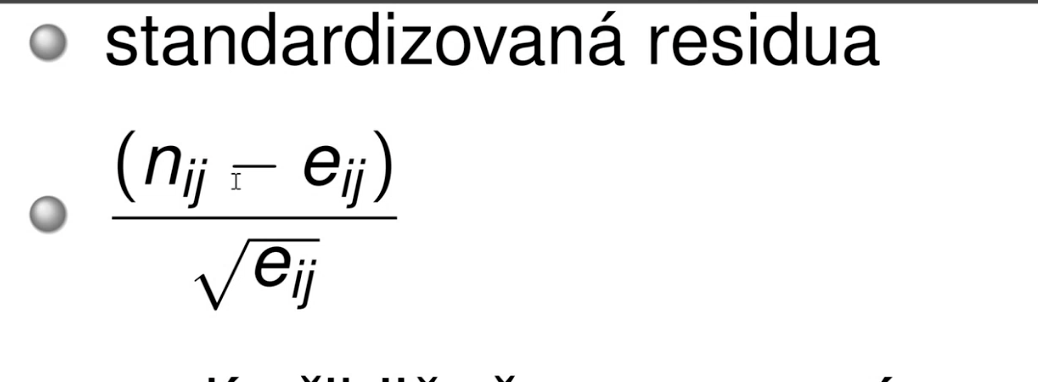

In [51]:
# Výpočet štandardizovaných rezíduí podľa tvojho vzorca
# Vektorizovaná operácia: (n_i - e_i) / sqrt(e_i)
residuals = (bmi_counts - expected) / np.sqrt(expected)

# Vytvoríme prehľadný DataFrame pre interpretáciu
analysis_df = pd.DataFrame({
    'Pozorované (n)': bmi_counts,
    'Očakávané (e)': expected,
    'Rezíduá': residuals
}, index=bmi_counts.index)

# Označíme kategórie, ktoré sú štatisticky významné (|rezíduum| > 1.96)
analysis_df['Významné'] = np.abs(analysis_df['Rezíduá']) > 1.96

print("--- Analýza rezíduí ---")
print(analysis_df)

--- Analýza rezíduí ---
               Pozorované (n)  Očakávané (e)    Rezíduá  Významné
BMI Category                                                     
Normal                    195           93.5  10.496880      True
Overweight                148           93.5   5.636256      True
Normal Weight              21           93.5  -7.497772      True
Obese                      10           93.5  -8.635364      True


* +10.49 tych co je Normal
* Overweight +5.49 je pomerne viac ako by malo byt (vsetky su nad ramec normalneho rozdelenia, ale z logiky veci Normal weight chcema by bolo co najviac)

---------------

# Test nezavislosti
* najvacsi rozdiel je ze pouzivam na dve kategoricke premenne a ako na seba suvisia
* napr ci BMI Category suvisi s Sleep Disorder

* kontingencna tabulka BMI category a Gender

In [52]:
# 3. Vytvorenie kontingenčnej tabuľky
# vzťah medzi 'BMI Category' a napr. 'Sleep Disorder' (Pohlavie)
# Funkcia crosstab spočíta výskyty pre každú kombináciu kategórií

# ct_auto = pd.crosstab(df['BMI Category'], df['Sleep Disorder'], margins=True, margins_name="Total")

contingency_table = pd.crosstab(df['BMI Category'], df['Sleep Disorder'])

print("\n--- Kontingenčná tabuľka ---")
print(contingency_table)


--- Kontingenčná tabuľka ---
Sleep Disorder  Insomnia  Sleep Apnea
BMI Category                         
Normal                 7            5
Normal Weight          2            2
Obese                  4            6
Overweight            64           65


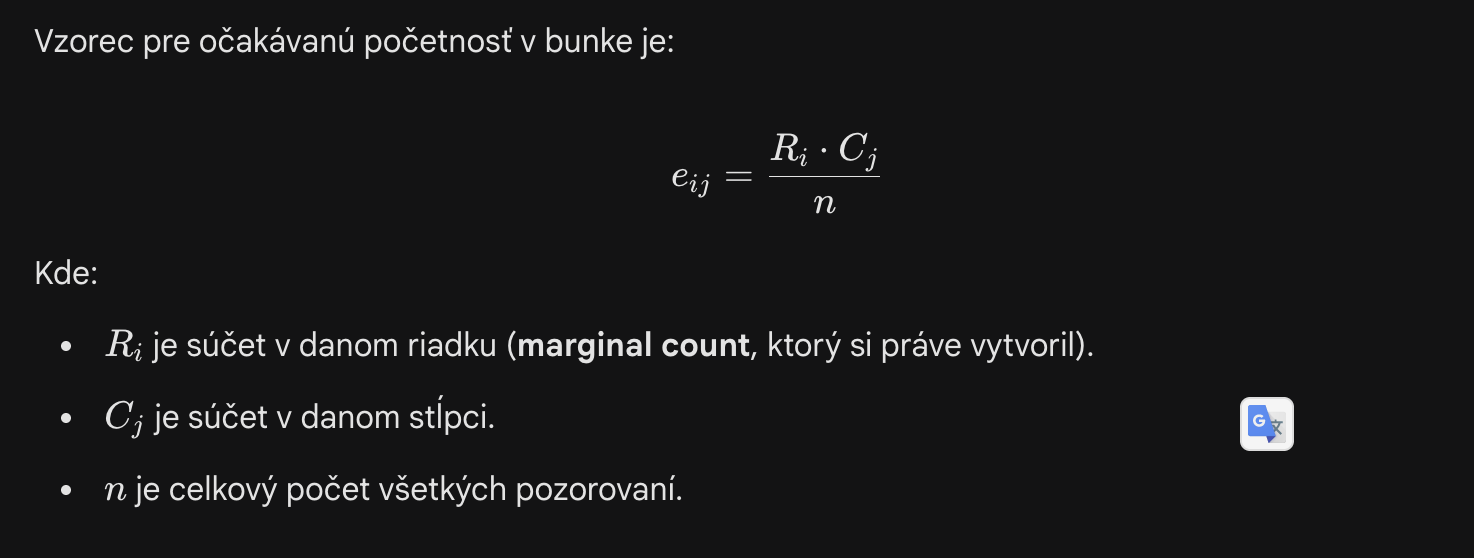

In [61]:
# automaticky hodnoty ei a test nezavislosti
# 1. Nahradíme chýbajúce hodnoty (NaN) v stĺpci Sleep Disorder hodnotou 'None'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# 2. Znova vytvoríme kontingenčnú tabuľku
ct = pd.crosstab(df['BMI Category'], df['Sleep Disorder'])

print("--- Opravená kontingenčná tabuľka ---")
print(ct)
print()

# 1. Najprv potrebujeme "čistú" kontingenčnú tabuľku (bez riadkov/stĺpcov Total)
# Ak si ich predtým pridal, urobíme si novú verziu pre výpočet
ct_clean = pd.crosstab(df['BMI Category'], df['Sleep Disorder'])

# 2. Spustíme test, ktorý nám vráti aj očakávané hodnoty (štvrtý výstup)
chi2, p, dof, expected_array = stats.chi2_contingency(ct_clean)

# 3. Prevedieme výsledné NumPy pole späť na prehľadný DataFrame
# Použijeme rovnaké názvy riadkov a stĺpcov ako v pôvodnej tabuľke
expected_df = pd.DataFrame(
    expected_array, 
    index=ct_clean.index, 
    columns=ct_clean.columns
)

print("--- Tabuľka očakávaných početností (eij) ---")
print(expected_df.round(2)) # Zaokrúhlime na 2 desatinné miesta pre čitateľnosť


--- Opravená kontingenčná tabuľka ---
Sleep Disorder  Insomnia  None  Sleep Apnea
BMI Category                               
Normal                 7   183            5
Normal Weight          2    17            2
Obese                  4     0            6
Overweight            64    19           65

--- Tabuľka očakávaných početností (eij) ---
Sleep Disorder  Insomnia    None  Sleep Apnea
BMI Category                                 
Normal             40.15  114.18        40.67
Normal Weight       4.32   12.30         4.38
Obese               2.06    5.86         2.09
Overweight         30.47   86.66        30.87


In [57]:
chi2, p, dof

(0.7346642375712145, 0.8650218472482434, 3)

In [62]:
residuals_df = (ct - expected_df) / np.sqrt(expected_df)

print("--- Tabuľka štandardizovaných rezíduí ---")
print(residuals_df.round(4))

# 2. Kontrola: Súčet štvorcov rezíduí sa musí rovnať tvojej Chi-kvadrát štatistike
chi_square_manual = (residuals_df**2).sum().sum()
print(f"\nManuálne overená Chi-square štatistika: {chi_square_manual:.4f}")

--- Tabuľka štandardizovaných rezíduí ---
Sleep Disorder  Insomnia    None  Sleep Apnea
BMI Category                                 
Normal           -5.2314  6.4400      -5.5931
Normal Weight    -1.1175  1.3412      -1.1371
Obese             1.3529 -2.4198       2.7106
Overweight        6.0742 -7.2683       6.1439

Manuálne overená Chi-square štatistika: 246.9682
